In [1]:
import torch

import matplotlib.pyplot as plt

from utils.masking import BinaryMasking
from utils.config import *

In [3]:
obj = ObjectiveConfig(event_dims={}, kwargs={'warmup': 0})
world = WorldConfig({'v': 9, "t": 48, 'h': 64, 'w':120}, patch_sizes={'vv':1, 'tt': 6, 'ww':4, 'hh':4}, batch_size=2)

In [ ]:

class BinaryMasking(torch.nn.Module):
    def __init__(self, 
                 world: WorldConfig, 
                 event_kwargs: dict = None, 
                 rate_kwargs: dict = None, 
                 epsilon: float = 1e-3):
        super().__init__()
        self.world = world
        
        self._event_kwargs = default(event_kwargs, {})
        self._rate_kwargs = default(rate_kwargs, {})

        self.register_buffer('epsilon', torch.tensor(epsilon))

    @property
    def device(self) -> torch.device: return self.epsilon.device

    @property
    def event_kwargs(self) -> dict:
        return self._event_kwargs
    
    @event_kwargs.setter
    def event_kwargs(self, update: dict):
        self._event_kwargs.update(update)

    @property
    def rate_kwargs(self) -> dict:
        return self._rate_kwargs
    
    @rate_kwargs.setter
    def rate_kwargs(self, update: dict):
        self._rate_kwargs.update(update)

    @staticmethod
    def binary_topk_(P: torch.FloatTensor, K: torch.LongTensor) -> torch.BoolTensor:
        return K > P.argsort(descending=True).argsort()

    def uniform_(self, shape: tuple, rng: torch.Generator):
        return torch.rand(*shape, device=self.device, generator=rng).clamp(self.epsilon, 1 - self.epsilon)

    def stratified_uniform_(self, B: int, rng: torch.Generator = None):
        L = torch.linspace(0, 1, B, device=self.device)
        U = torch.rand((1,), device=self.device, generator=rng)
        return (L + U).remainder(1).clamp(self.epsilon, 1 - self.epsilon)

    def event_prior(self, B: int, conditional: torch.Tensor = None, rng: torch.Generator = None):
        F = self.uniform_((B, self.world.num_tokens), rng).log().div(self.event_kwargs.get('base', 1.))
        for dim, alpha in self.event_kwargs.items():
            if dim not in self.world.layout:
                continue
            U = self.uniform_((B, self.world.token_sizes[dim]), rng)
            U = einops.repeat(U, f'b {dim} -> b ({self.world.token_pattern})', **self.world.token_sizes)
            F += U.log().div(alpha)
        if exists(conditional):
            F += conditional.type_as(F).clamp(min=1e-12).log()
        return F

    def rate_prior(self, B: int, rng: torch.Generator = None):
        a_min = self.rate_kwargs.get('min', 0)
        a_max = self.rate_kwargs.get('max', 1)
        U = self.stratified_uniform_(B, rng) if self.rate_kwargs.get('stratify', False) else self.uniform_((B,), rng)
        R = U * (a_max - a_min) + a_min
        return R.mul(self.world.num_tokens).long().unsqueeze(-1)

    def forward(self, B: int, conditional: torch.Tensor = None, rng: torch.Generator = None) -> torch.BoolTensor:
        B = B[0] if isinstance(B, tuple) else B
        K = self.rate_prior(B, rng)
        P = self.event_prior(B, conditional=conditional, rng=rng)
        return self.binary_topk_(P, K)


In [45]:
bm = BinaryMasking(world)

print(bm.event_kwargs)

bm.event_kwargs = {'base': 1e-9}
print(bm.event_kwargs)

bm.event_kwargs = {'base': 1e-8, "min": 0.1}
print(bm.event_kwargs)

{}
{'base': 1e-09}
{'base': 1e-08, 'min': 0.1}


In [37]:
bm((2,))

tensor([[False,  True,  True,  ...,  True, False, False],
        [False,  True,  True,  ..., False,  True,  True]])

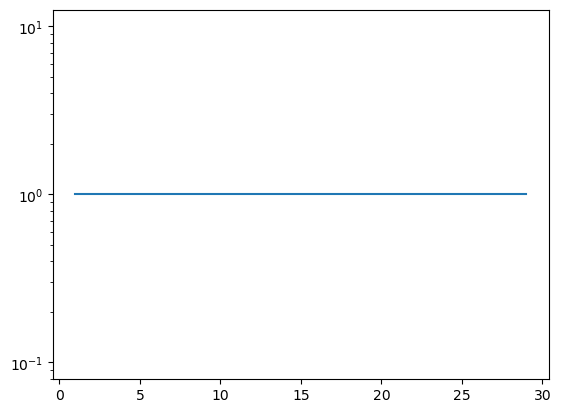

In [28]:
epochs = torch.arange(30)

plt.semilogy(epochs, [base_alpha(e, obj.kwargs.get('warmup')) for e in epochs])